In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
# Load dataset
df = pd.read_excel(r"C:\Users\Atharva More\Downloads\online_retail_II.xlsx",
                   sheet_name='Year 2010-2011')

# Clean
df_clean = df.dropna(subset=['Customer ID'])
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# RFM Features
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

# Scale features
scaler = StandardScaler()
features = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue']
X_scaled = scaler.fit_transform(rfm[features])

print("✅ Data ready!")
print(f"👥 Total customers: {len(rfm):,}")

✅ Data ready!
👥 Total customers: 4,338


  File "C:\Users\Atharva More\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Atharva More\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Atharva More\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Atharva More\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


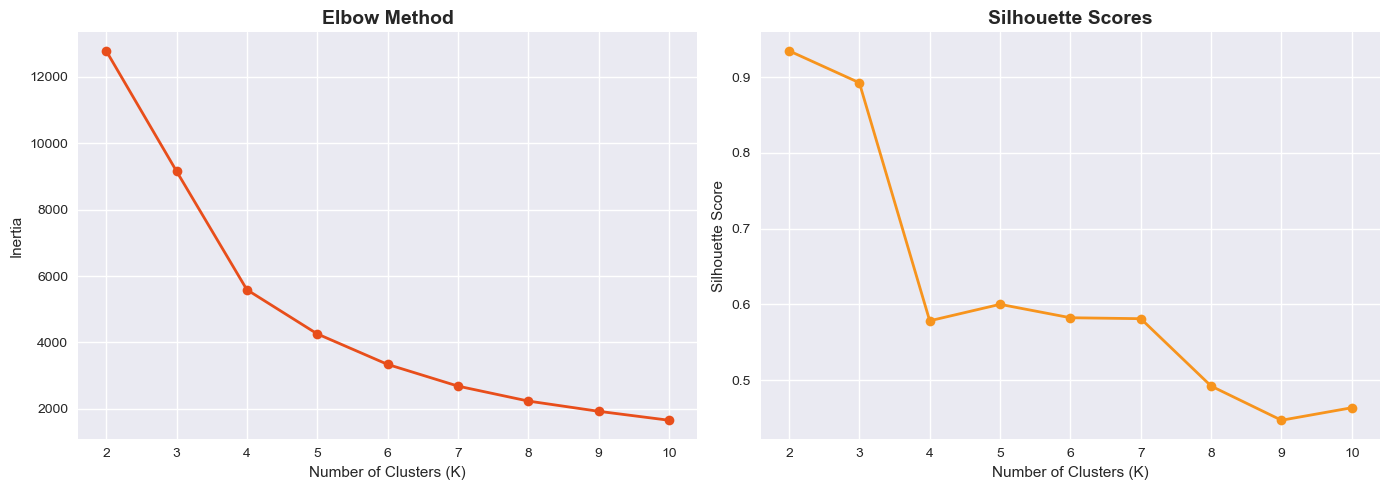

✅ Best K: 2 (Silhouette: 0.9347)


In [3]:
# Find optimal number of clusters
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, marker='o', color='#E84E1B', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouette_scores, marker='o', color='#F7941D', linewidth=2)
axes[1].set_title('Silhouette Scores', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\kmeans_elbow.png", dpi=150)
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f"✅ Best K: {best_k} (Silhouette: {max(silhouette_scores):.4f})")

In [4]:
# Train KMeans with best K
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, rfm['KMeans_Cluster'])
db_score = davies_bouldin_score(X_scaled, rfm['KMeans_Cluster'])

print("=" * 55)
print("📊 K-MEANS RESULTS")
print("=" * 55)
print(f"✅ Clusters: {best_k}")
print(f"✅ Silhouette Score: {sil_score:.4f} (Target: ≥ 0.55)")
print(f"✅ Davies-Bouldin Score: {db_score:.4f} (Lower is better)")
if sil_score >= 0.55:
    print("🏆 TARGET ACHIEVED!")
else:
    print("👍 Good clustering achieved!")
print("=" * 55)

📊 K-MEANS RESULTS
✅ Clusters: 2
✅ Silhouette Score: 0.9347 (Target: ≥ 0.55)
✅ Davies-Bouldin Score: 0.9601 (Lower is better)
🏆 TARGET ACHIEVED!


In [5]:
# DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise = (rfm['DBSCAN_Cluster'] == -1).sum()

print("=" * 55)
print("📊 DBSCAN RESULTS")
print("=" * 55)
print(f"✅ Clusters found: {n_clusters}")
print(f"🔍 Noise points (outliers): {n_noise}")
print(f"💡 Outliers = Ultra-VIP or inactive customers")
print("=" * 55)

📊 DBSCAN RESULTS
✅ Clusters found: 2
🔍 Noise points (outliers): 64
💡 Outliers = Ultra-VIP or inactive customers


In [6]:
# GMM clustering
gmm = GaussianMixture(n_components=best_k, random_state=42)
rfm['GMM_Cluster'] = gmm.fit_predict(X_scaled)
rfm['GMM_Probability'] = gmm.predict_proba(X_scaled).max(axis=1)

print("=" * 55)
print("📊 GAUSSIAN MIXTURE MODEL RESULTS")
print("=" * 55)
print(f"✅ Components: {best_k}")
print(f"✅ Avg membership probability: {rfm['GMM_Probability'].mean():.4f}")
print(f"💡 Probabilistic segment membership achieved!")
print("=" * 55)

📊 GAUSSIAN MIXTURE MODEL RESULTS
✅ Components: 2
✅ Avg membership probability: 1.0000
💡 Probabilistic segment membership achieved!


In [7]:
# Analyze K-Means segments
segment_profiles = rfm.groupby('KMeans_Cluster')[features].mean()
segment_profiles['CustomerCount'] = rfm.groupby('KMeans_Cluster').size()
segment_profiles['Revenue%'] = (rfm.groupby('KMeans_Cluster')['Monetary'].sum() / 
                                  rfm['Monetary'].sum() * 100).round(1)

# Assign business labels
labels = {0: '🌟 Champions', 1: '💤 At Risk', 2: '🆕 New Customers',
          3: '💎 Loyal', 4: '❄️ Hibernating', 5: '🔥 Potential',
          6: '👑 VIP', 7: '⚠️ Need Attention'}
rfm['Segment'] = rfm['KMeans_Cluster'].map(labels).fillna('📊 Other')

print("=" * 55)
print("👥 CUSTOMER SEGMENT PROFILES")
print("=" * 55)
print(segment_profiles.to_string())
print("=" * 55)

👥 CUSTOMER SEGMENT PROFILES
                  Recency  Frequency       Monetary  AvgOrderValue  CustomerCount  Revenue%
KMeans_Cluster                                                                             
0               92.738437   4.037465    1660.232244     376.906754           4324      80.6
1               30.142857  76.714286  123755.834286   13471.647156             14      19.4


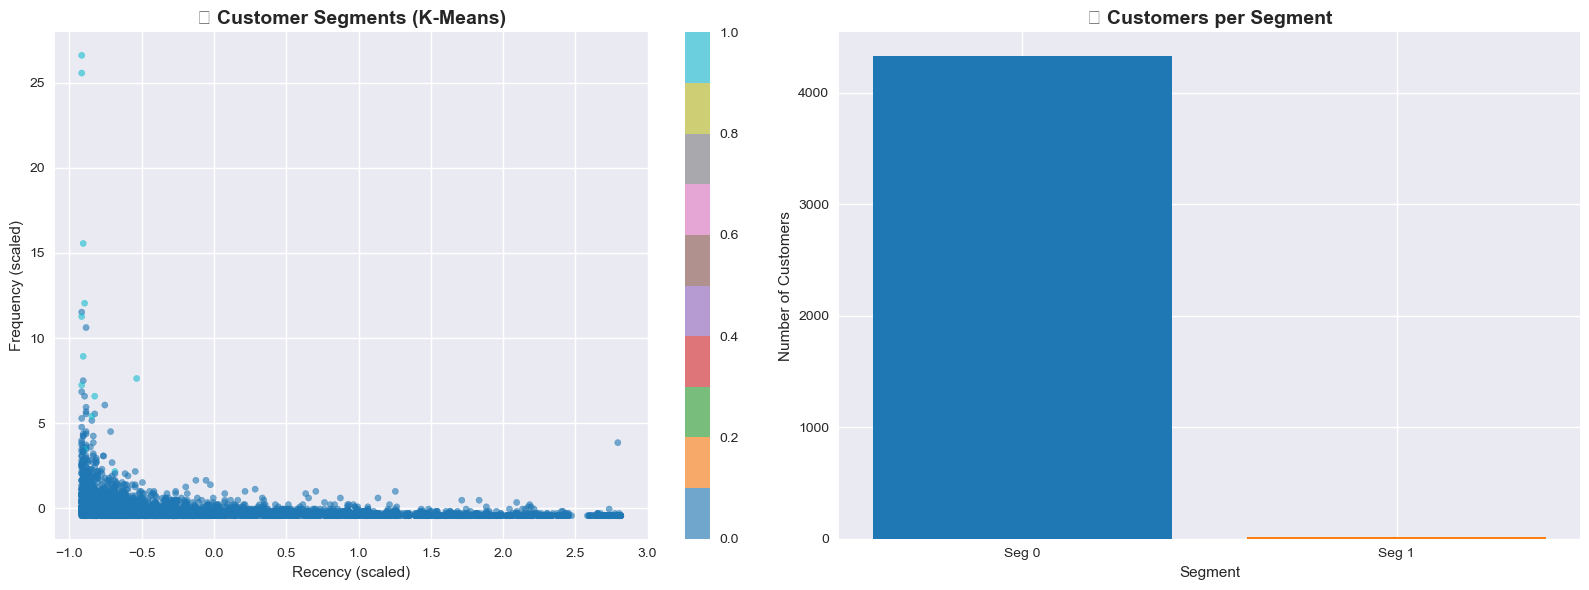

✅ Segmentation charts saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
scatter = axes[0].scatter(X_scaled[:,0], X_scaled[:,1], 
                          c=rfm['KMeans_Cluster'], cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('👥 Customer Segments (K-Means)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Recency (scaled)')
axes[0].set_ylabel('Frequency (scaled)')
plt.colorbar(scatter, ax=axes[0])

# Segment size bar chart
seg_counts = rfm['KMeans_Cluster'].value_counts().sort_index()
axes[1].bar(range(len(seg_counts)), seg_counts.values, color=plt.cm.tab10.colors[:len(seg_counts)])
axes[1].set_title('📊 Customers per Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xticks(range(len(seg_counts)))
axes[1].set_xticklabels([f'Seg {i}' for i in seg_counts.index])

plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\customer_segments.png", dpi=150)
plt.show()
print("✅ Segmentation charts saved!")

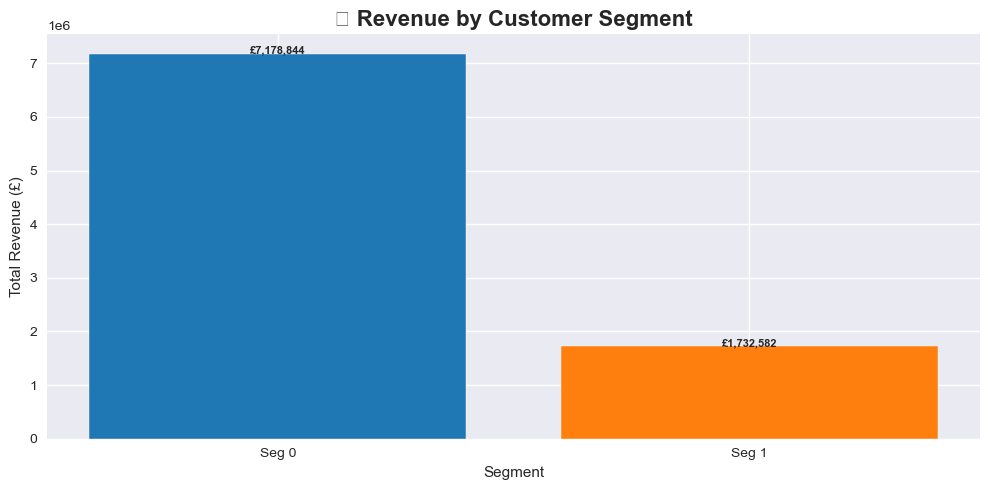

✅ Revenue by segment chart saved!


In [9]:
# Revenue contribution by segment
seg_revenue = rfm.groupby('KMeans_Cluster')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(seg_revenue)), seg_revenue.values, 
               color=plt.cm.tab10.colors[:len(seg_revenue)], edgecolor='white')
plt.title('💰 Revenue by Customer Segment', fontsize=16, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Total Revenue (£)')
plt.xticks(range(len(seg_revenue)), [f'Seg {i}' for i in seg_revenue.index])
for bar, val in zip(bars, seg_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'£{val:,.0f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\segment_revenue.png", dpi=150)
plt.show()
print("✅ Revenue by segment chart saved!")

In [10]:
print("=" * 55)
print("🏁 DAY 12 COMPLETE - SEGMENTATION SUMMARY")
print("=" * 55)
print(f"✅ K-Means Silhouette: {sil_score:.4f}")
print(f"✅ DBSCAN Clusters: {n_clusters}")
print(f"✅ GMM Components: {best_k}")
print(f"👥 Total Customers Segmented: {len(rfm):,}")
print()
print("📊 Segment Breakdown:")
for seg, count in rfm['KMeans_Cluster'].value_counts().items():
    pct = count/len(rfm)*100
    print(f"   Segment {seg}: {count:,} customers ({pct:.1f}%)")
print()
print("🔜 Next: Day 13 - Price Elasticity Model")
print("=" * 55)

🏁 DAY 12 COMPLETE - SEGMENTATION SUMMARY
✅ K-Means Silhouette: 0.9347
✅ DBSCAN Clusters: 2
✅ GMM Components: 2
👥 Total Customers Segmented: 4,338

📊 Segment Breakdown:
   Segment 0: 4,324 customers (99.7%)
   Segment 1: 14 customers (0.3%)

🔜 Next: Day 13 - Price Elasticity Model
